In [2]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Carga desde un archivo .csv sin indice
plazas= pd.read_csv('Analisis GAC Full7agosto 2026(Plazas).csv') 

C:\Users\maria\AppData\Local\Temp\ipykernel_6768\500712103.py:2: DtypeWarning: Columns (0: Fecha Origen, 1: Nombre, 2: Producto, 3: Asesor, 4: Origen, 5: Seguimiento, 6: Cita efetiva , 7: PDM, 8: SDC, 9: Estatus, 10: ¿Por que no hay seguimiento?, 11: ¿Por que no ha visitado la agencia?, 12: ¿Por que no hubo prueba de manejo ?, 13: ¿Por que no hubo solicitud de credito?, 14: ¿Por que no se ha formalizado la compra?, 15: Unnamed: 16, 16: Unnamed: 19) have mixed types. Specify dtype option on import or set low_memory=False.
  plazas= pd.read_csv('Analisis GAC Full7agosto 2026(Plazas).csv')


In [4]:
#Verificamos información del DataFrame
plazas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 20 columns):
 #   Column                                    Non-Null Count    Dtype  
---  ------                                    --------------    -----  
 0   Fecha Origen                              302 non-null      str    
 1   Nombre                                    303 non-null      str    
 2   Telefono                                  26 non-null       float64
 3   Producto                                  303 non-null      str    
 4   Asesor                                    303 non-null      str    
 5   Origen                                    303 non-null      str    
 6   Seguimiento                               1048567 non-null  object 
 7   Cita efetiva                              1048564 non-null  object 
 8   PDM                                       1048563 non-null  object 
 9   SDC                                       1048563 non-null  object 
 10  Estatus          

In [5]:
#Imprimo los primeros 5 registro del dataframe
plazas.head()

,Fecha Origen,Nombre,Telefono,Producto,Asesor,Origen,Seguimiento,Cita efetiva,PDM,SDC,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,05/06/2025 18:30,Alejandro Fernandez,NaN,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,True,False,False,False,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,05/06/2025 18:00,David Israel,NaN,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,True,False,False,False,Finalizado,Si hay seguimiento,Dejo de contestar,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,05/06/2025 13:50,Rosendo Ceron,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05/06/2025 13:47,Fausto Ochoa Martinez,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05/06/2025 13:43,Brigida Lara Perez,NaN,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,True,False,False,False,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",NaN,NaN,NaN,NaN,NaN,NaN,NaN


¿Por que no se ha formalizado la compra?

In [6]:
# Extraigo la pregunta abierta
Pregunta_abierta = plazas[
    ["¿Por que no se ha formalizado la compra?"]
].copy()

# Elimino las respuestas vacías
Pregunta_abierta = Pregunta_abierta.dropna()

Pregunta_abierta

,¿Por que no se ha formalizado la compra?
7,Quiere vender su unidad para el enganche
9,Financiera pidio referencia
16,Esta evaluando sus gastos
17,Esta evaluando marcas
21,Ya se facturo la unidad
25,Necesita vender MGpara hacer su compra
28,Quiere vender su unidad
44,"Cuando se tome, avanza con su credito"
64,"Tiene una changan, salio de viaje"
69,Ya se facturo


In [7]:
Pregunta_abierta["Caracteristica"] = "Otro"

In [8]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "vender su unidad|vender mg|valuación|valuacion",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Venta de unidad actual"

In [9]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "evaluando|gastos|marcas|que unidad",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Evaluación o indecisión"

In [10]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "financiera|credito|crédito|referencia",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Financiamiento"

In [11]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "no contesta|dejo de contestar|dejó de contestar|no responde",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Falta de respuesta"

In [12]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "no contesta|dejo de contestar|dejó de contestar|no responde",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Falta de respuesta"

In [13]:
Pregunta_abierta.loc[

    Pregunta_abierta["¿Por que no se ha formalizado la compra?"]

    .str.contains(
        "facturo|facturó|aparto|apartó",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Compra formalizada"

In [14]:
Pregunta_abierta

,¿Por que no se ha formalizado la compra?,Caracteristica
7,Quiere vender su unidad para el enganche,Venta de unidad actual
9,Financiera pidio referencia,Financiamiento
16,Esta evaluando sus gastos,Evaluación o indecisión
17,Esta evaluando marcas,Evaluación o indecisión
21,Ya se facturo la unidad,Compra formalizada
25,Necesita vender MGpara hacer su compra,Venta de unidad actual
28,Quiere vender su unidad,Venta de unidad actual
44,"Cuando se tome, avanza con su credito",Financiamiento
64,"Tiene una changan, salio de viaje",Otro
69,Ya se facturo,Compra formalizada


In [15]:
Tabla_caracteristicas = (

    Pregunta_abierta["Caracteristica"]

    .value_counts()

    .reset_index()

)

Tabla_caracteristicas

,Caracteristica,count
0,Venta de unidad actual,3
1,Evaluación o indecisión,3
2,Compra formalizada,3
3,Financiamiento,2
4,Falta de respuesta,2
5,Otro,1


In [16]:
Tabla_caracteristicas = (
    Pregunta_abierta["Caracteristica"]
    .value_counts()
    .reset_index()
)

Tabla_caracteristicas.columns = ["Caracteristica", "Frecuencia"]

Tabla_caracteristicas

,Caracteristica,Frecuencia
0,Venta de unidad actual,3
1,Evaluación o indecisión,3
2,Compra formalizada,3
3,Financiamiento,2
4,Falta de respuesta,2
5,Otro,1


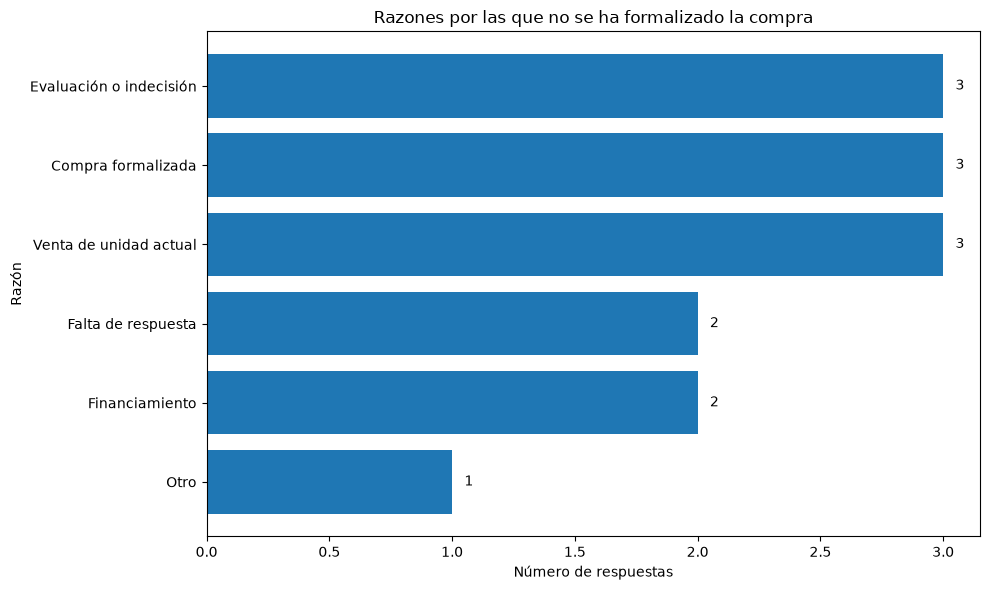

In [17]:
import matplotlib.pyplot as plt

# Ordeno las categorías
Tabla_caracteristicas = Tabla_caracteristicas.sort_values(
    by="Frecuencia",
    ascending=True
)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    Tabla_caracteristicas["Caracteristica"],
    Tabla_caracteristicas["Frecuencia"]
)

# Agrego el número de respuestas al final de cada barra
for barra in barras:

    ancho = barra.get_width()

    plt.text(
        ancho + 0.05,
        barra.get_y() + barra.get_height()/2,
        int(ancho),
        va="center"
    )

plt.title("Razones por las que no se ha formalizado la compra")
plt.xlabel("Número de respuestas")
plt.ylabel("Razón")

plt.tight_layout()
plt.show()